# Research Proposal - AI for Drug Discovery 
### Eleni Psaromatis, MSc Digital Chemistry with AI and Automation, Imperial College London

# Preliminaries Section

### Import Libraries

In [44]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
from rdkit.Chem import RDConfig
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import rdMolDraw2D
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import umap
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import BaseEstimator, TransformerMixin
import random
import os
import sys
import sascorer

## Part 1

In [ ]:
df = pd.read_csv(' IC50-GR.csv path file should be here', sep=';') # update path to your local file for GR bioactivity data

# Keep only binding assays
df = df[df['Assay Type'] == 'B']

df = df.dropna(subset=['Smiles', 'pChEMBL Value'])
df = df.groupby('Smiles')['pChEMBL Value'].median().reset_index()

df['Active'] = (df['pChEMBL Value'] >= 6).astype(int)

print(f"Total compounds: {len(df)}")
print(f"Active (pChEMBL >= 6): {df['Active'].sum()}")
print(f"Inactive (pChEMBL < 6): {(df['Active'] == 0).sum()}")
print(f"Active fraction: {df['Active'].mean():.2f}")

df['mol'] = df['Smiles'].apply(Chem.MolFromSmiles)
df = df[df['mol'].notna()]
print(f"Valid SMILES remaining: {len(df)}")

Total compounds: 1867
Active (pChEMBL >= 6): 1604
Inactive (pChEMBL < 6): 263
Active fraction: 0.86
Valid SMILES remaining: 1867


In [18]:
# Change activity threshold to pChEMBL >= 7 to improve class balance
df['Active'] = (df['pChEMBL Value'] >= 7).astype(int)

print(f"Total compounds: {len(df)}")
print(f"Active (pChEMBL >= 7): {df['Active'].sum()}")
print(f"Inactive (pChEMBL < 7): {(df['Active'] == 0).sum()}")
print(f"Active fraction: {df['Active'].mean():.2f}")

Total compounds: 1867
Active (pChEMBL >= 7): 1108
Inactive (pChEMBL < 7): 759
Active fraction: 0.59


In [46]:
# Generate Morgan fingerprints 
def mol_to_fp(mol):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    arr = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X = np.array([mol_to_fp(mol) for mol in df['mol']])
y = df['Active'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} compounds")
print(f"Test set: {X_test.shape[0]} compounds")

# Train Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC on test set: {auc:.3f}")

[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerator
[20:24:35] DEPRECATION WARNING: please use MorganGenerat

Training set: 1493 compounds
Test set: 374 compounds
ROC-AUC on test set: 0.930


In [32]:
# Second approach for handling class imbalance

class BalancingTransformer(BaseEstimator, TransformerMixin):
    """
    Computes per-sample weights to balance class distribution.
    Equivalent to class_weight='balanced' but works with any estimator
    that accepts sample_weight in fit(), not just those with class_weight.
    """
    def fit(self, X, y):
        self.sample_weights_ = compute_sample_weight('balanced', y)
        return self

    def transform(self, X):
        return X  

# BalancingTransformer
balancer = BalancingTransformer().fit(X_train, y_train)

rf_bt = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bt.fit(X_train, y_train, sample_weight=balancer.sample_weights_)

auc_bt = roc_auc_score(y_test, rf_bt.predict_proba(X_test)[:, 1])

n_active   = (y_train == 1).sum()
n_inactive = (y_train == 0).sum()
w_active   = balancer.sample_weights_[y_train == 1][0]
w_inactive = balancer.sample_weights_[y_train == 0][0]
print(f"Training set: {n_active} actives and {n_inactive} inactives")
print(f"Weight per active sample:   {w_active:.3f}")
print(f"Weight per inactive sample: {w_inactive:.3f}")
print(f"ROC-AUC with BalancingTransformer: {auc_bt:.3f}")

Training set: 886 actives and 607 inactives
Weight per active sample:   0.843
Weight per inactive sample: 1.230
ROC-AUC with BalancingTransformer: 0.930


## Part 2

In [ ]:
known_compounds = {
    'Dexamethasone':    {'smiles': 'C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@@H]3[C@@H](O)C[C@]2(C)[C@]1(O)C(=O)CO',
                         'type': 'Classical GC', 'TA': 'Full', 'TR': 'Full'},
    'Prednisolone': {'smiles': 'O=C(CO)[C@@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@@H]3[C@@H](O)C[C@@]21C',
                        'type': 'Classical GC', 'TA': 'Full', 'TR': 'Full'},
    'Compound A':       {'smiles': 'O=C1OC2=CC=CC=C2/C1=C\\C1=CC=C(OCC2=CC=NO2)C=C1',
                         'type': 'SEGRIM', 'TA': 'None', 'TR': 'Full'},
    'ZK 216348':        {'smiles': 'CC1=CC=C(C=C1)S(=O)(=O)N1CC(C1)NC(=O)C1=CC2=CC=CC=C2O1',
                         'type': 'SEGRIM', 'TA': 'Partial', 'TR': 'Full'},
    'Mapracorat':       {'smiles': 'CC1=CC=C(C=C1)[C@@H]1[C@H](C(=O)NCC2=CC=CC=C2F)CC3=CC(F)=CC=C13',
                         'type': 'SEGRIM', 'TA': 'Partial', 'TR': 'Full'},
}

rows = []
for name, info in known_compounds.items():
    mol = Chem.MolFromSmiles(info['smiles'])
    if mol:
        rows.append({'Name': name, 'SMILES': info['smiles'],
                     'Type': info['type'], 'TA': info['TA'], 'TR': info['TR'], 'mol': mol})
    else:
        print(f"Invalid SMILES for {name}")

known_df = pd.DataFrame(rows)
print(known_df[['Name', 'Type', 'TA', 'TR']])

            Name          Type       TA    TR
0  Dexamethasone  Classical GC     Full  Full
1   Prednisolone  Classical GC     Full  Full
2     Compound A        SEGRIM     None  Full
3      ZK 216348        SEGRIM  Partial  Full
4     Mapracorat        SEGRIM  Partial  Full


[20:08:00] DEPRECATION WARNING: please use MorganGenerator
[20:08:00] DEPRECATION WARNING: please use MorganGenerator
[20:08:00] DEPRECATION WARNING: please use MorganGenerator
[20:08:00] DEPRECATION WARNING: please use MorganGenerator
[20:08:00] DEPRECATION WARNING: please use MorganGenerator


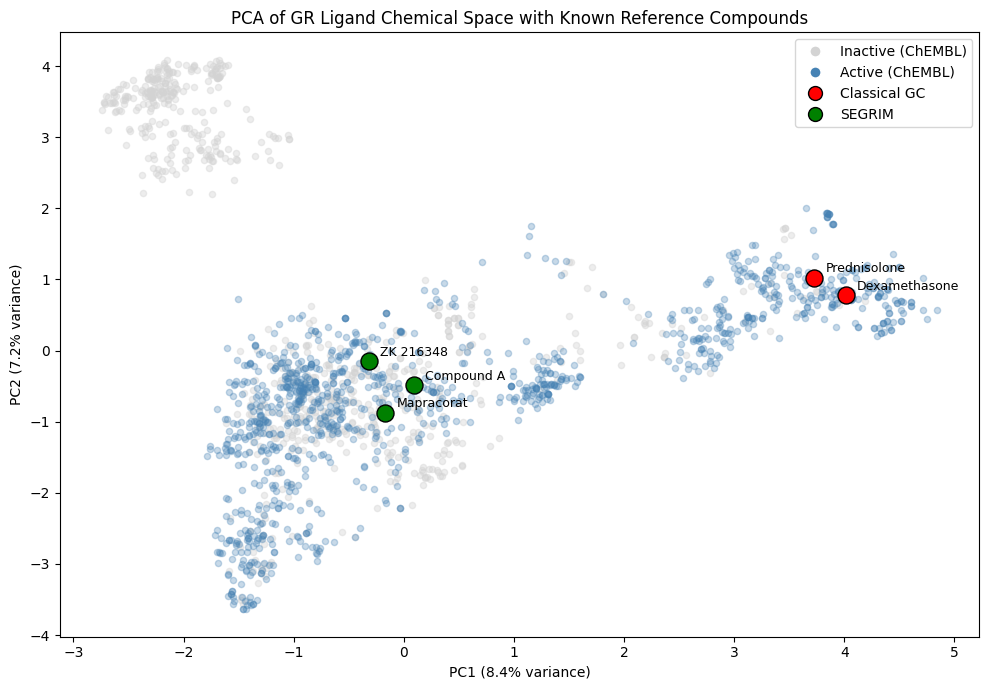


Variance explained: PC1=8.4%, PC2=7.2%


In [34]:
# PCA of chemical space with known compounds highlighted
known_fps = np.array([mol_to_fp(mol) for mol in known_df['mol']])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
known_pca = pca.transform(known_fps)

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1], 
                     c='lightgrey', alpha=0.4, s=20, label='Inactive (ChEMBL)')
ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1], 
           c='steelblue', alpha=0.3, s=20, label='Active (ChEMBL)')

colours = {'Classical GC': 'red', 'SEGRIM': 'green'}
for _, row in known_df.iterrows():
    idx = list(known_df['Name']).index(row['Name'])
    ax.scatter(known_pca[idx, 0], known_pca[idx, 1],
               c=colours[row['Type']], s=150, zorder=5,
               edgecolors='black', linewidths=1)
    ax.annotate(row['Name'], (known_pca[idx, 0], known_pca[idx, 1]),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey', markersize=8, label='Inactive (ChEMBL)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Active (ChEMBL)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Classical GC', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='SEGRIM', markeredgecolor='black'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of GR Ligand Chemical Space with Known Reference Compounds')
plt.tight_layout()
plt.show()

print(f"\nVariance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


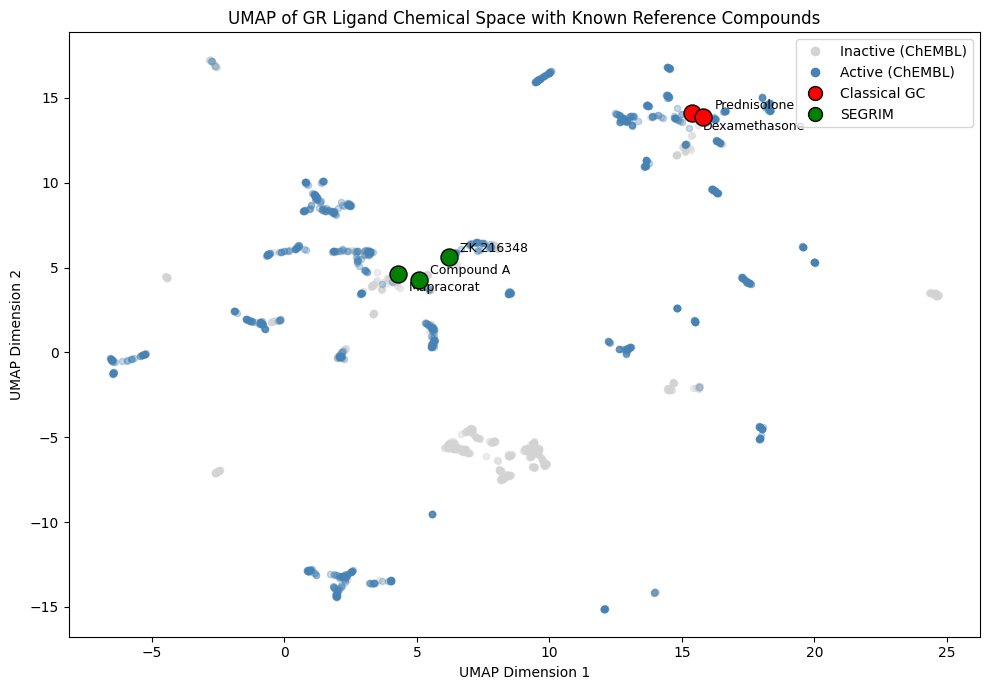

In [10]:
# Due to the limited variance captured by PCA, we can also try UMAP for better separation of known compounds in chemical space

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X)
known_umap = reducer.transform(known_fps)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(X_umap[y==0, 0], X_umap[y==0, 1],
           c='lightgrey', alpha=0.4, s=20, label='Inactive (ChEMBL)')
ax.scatter(X_umap[y==1, 0], X_umap[y==1, 1],
           c='steelblue', alpha=0.3, s=20, label='Active (ChEMBL)')

colours = {'Classical GC': 'red', 'SEGRIM': 'green'}

label_offsets = {
    'Dexamethasone': (8, -12),
    'Prednisolone':  (8, 6),
    'Compound A':    (8, 4),
    'ZK 216348':     (8, 4),
    'Mapracorat':    (8, -12),
}

for _, row in known_df.iterrows():
    idx = list(known_df['Name']).index(row['Name'])
    ax.scatter(known_umap[idx, 0], known_umap[idx, 1],
               c=colours[row['Type']], s=150, zorder=5,
               edgecolors='black', linewidths=1)
    offset = label_offsets.get(row['Name'], (8, 4))
    ax.annotate(row['Name'], (known_umap[idx, 0], known_umap[idx, 1]),
                textcoords='offset points', xytext=offset, fontsize=9)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markersize=8, label='Inactive (ChEMBL)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Active (ChEMBL)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Classical GC', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=10, label='SEGRIM', markeredgecolor='black'),
]

ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title('UMAP of GR Ligand Chemical Space with Known Reference Compounds')
plt.tight_layout()
plt.show()

## part 3

In [ ]:
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))

compound_a_mol = known_df[known_df['Name'] == 'Compound A']['mol'].values[0]
sa = sascorer.calculateScore(compound_a_mol)
print(f"Compound A SA Score: {sa:.2f}")
# SA Score: 1=easy to synthesise and 10=very difficult

Compound A SA Score: 2.46


In [40]:
def lipinski(mol):
    """Returns True if molecule passes Lipinski's rule of five"""
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    return mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10

def sa_score(mol):
    return sascorer.calculateScore(mol)

mw = Descriptors.MolWt(compound_a_mol)
logp = Descriptors.MolLogP(compound_a_mol)
hbd = Descriptors.NumHDonors(compound_a_mol)
hba = Descriptors.NumHAcceptors(compound_a_mol)

print("Compound A properties:")
print(f"  Molecular weight: {mw:.2f} (limit: ≤500)")
print(f"  LogP: {logp:.2f} (limit: ≤5)")
print(f"  H-bond donors: {hbd} (limit: ≤5)")
print(f"  H-bond acceptors: {hba} (limit: ≤10)")
print(f"  Passes Lipinski: {lipinski(compound_a_mol)}")
print(f"  SA Score: {sa_score(compound_a_mol):.2f}")

Compound A properties:
  Molecular weight: 319.32 (limit: ≤500)
  LogP: 3.71 (limit: ≤5)
  H-bond donors: 0 (limit: ≤5)
  H-bond acceptors: 5 (limit: ≤10)
  Passes Lipinski: True
  SA Score: 2.46


In [ ]:
# Get Murcko scaffold of Compound A
scaffold = MurckoScaffold.GetScaffoldForMol(compound_a_mol)
scaffold_smiles = Chem.MolToSmiles(scaffold)
print(f"Compound A Murcko scaffold: {scaffold_smiles}")

# common substituents to try adding to the scaffold
substituents = [
    'F', 'Cl', 'Br',           
    'C',                        
    'OC',                      
    'N',                        
    'C(=O)N',                   
    'S(=O)(=O)N',              
    'C#N',                      
    'OC(=O)C',                 
]

analogues = []
compound_a_smiles = Chem.MolToSmiles(compound_a_mol)

for sub in substituents:
    for position in ['c1ccc(', 'c1cc(', 'C(']:
        try:
            new_smiles = compound_a_smiles.replace(
                position, position + sub, 1)
            mol = Chem.MolFromSmiles(new_smiles)
            if mol is not None:
                analogues.append({
                    'smiles': new_smiles,
                    'mol': mol,
                    'substituent': sub
                })
        except:
            continue

print(f"Generated {len(analogues)} initial analogues")

filtered = []
for a in analogues:
    mol = a['mol']
    if lipinski(mol) and sa_score(mol) <= 4.0:
        filtered.append({
            'smiles': a['smiles'],
            'MW': round(Descriptors.MolWt(mol), 2),
            'LogP': round(Descriptors.MolLogP(mol), 2),
            'HBD': Descriptors.NumHDonors(mol),
            'HBA': Descriptors.NumHAcceptors(mol),
            'SA_Score': round(sa_score(mol), 2),
            'Substituent': a['substituent']
        })

filtered_df = pd.DataFrame(filtered).drop_duplicates(subset='smiles')
print(f"Analogues passing Lipinski and SA ≤ 4.0: {len(filtered_df)}")
print(filtered_df[['smiles', 'MW', 'LogP', 'SA_Score']].head(10))

Compound A Murcko scaffold: O=C1Oc2ccccc2/C1=C\c1ccc(OCc2ccno2)cc1
Generated 26 initial analogues
Analogues passing Lipinski and SA ≤ 4.0: 7
                                              smiles      MW  LogP  SA_Score
0             O=C1Oc2ccccc2/C1=C\c1ccc(OCc2ccno2)cc1  319.32  3.71      2.46
6            O=C1Oc2ccccc2/C1=C\c1ccc(COCc2ccno2)cc1  333.34  3.85      2.55
9           O=C1Oc2ccccc2/C1=C\c1ccc(OCOCc2ccno2)cc1  349.34  3.69      2.65
12           O=C1Oc2ccccc2/C1=C\c1ccc(NOCc2ccno2)cc1  334.33  3.68      2.78
15      O=C1Oc2ccccc2/C1=C\c1ccc(C(=O)NOCc2ccno2)cc1  362.34  3.00      2.71
18  O=C1Oc2ccccc2/C1=C\c1ccc(S(=O)(=O)NOCc2ccno2)cc1  398.40  2.54      2.84
23     O=C1Oc2ccccc2/C1=C\c1ccc(OC(=O)COCc2ccno2)cc1  377.35  3.26      2.67


[20:12:33] Explicit valence for atom # 15 F, 2, is greater than permitted
[20:12:33] Explicit valence for atom # 15 Cl, 2, is greater than permitted
[20:12:33] Explicit valence for atom # 15 Br, 2, is greater than permitted
[20:12:33] Explicit valence for atom # 16 N, 4, is greater than permitted


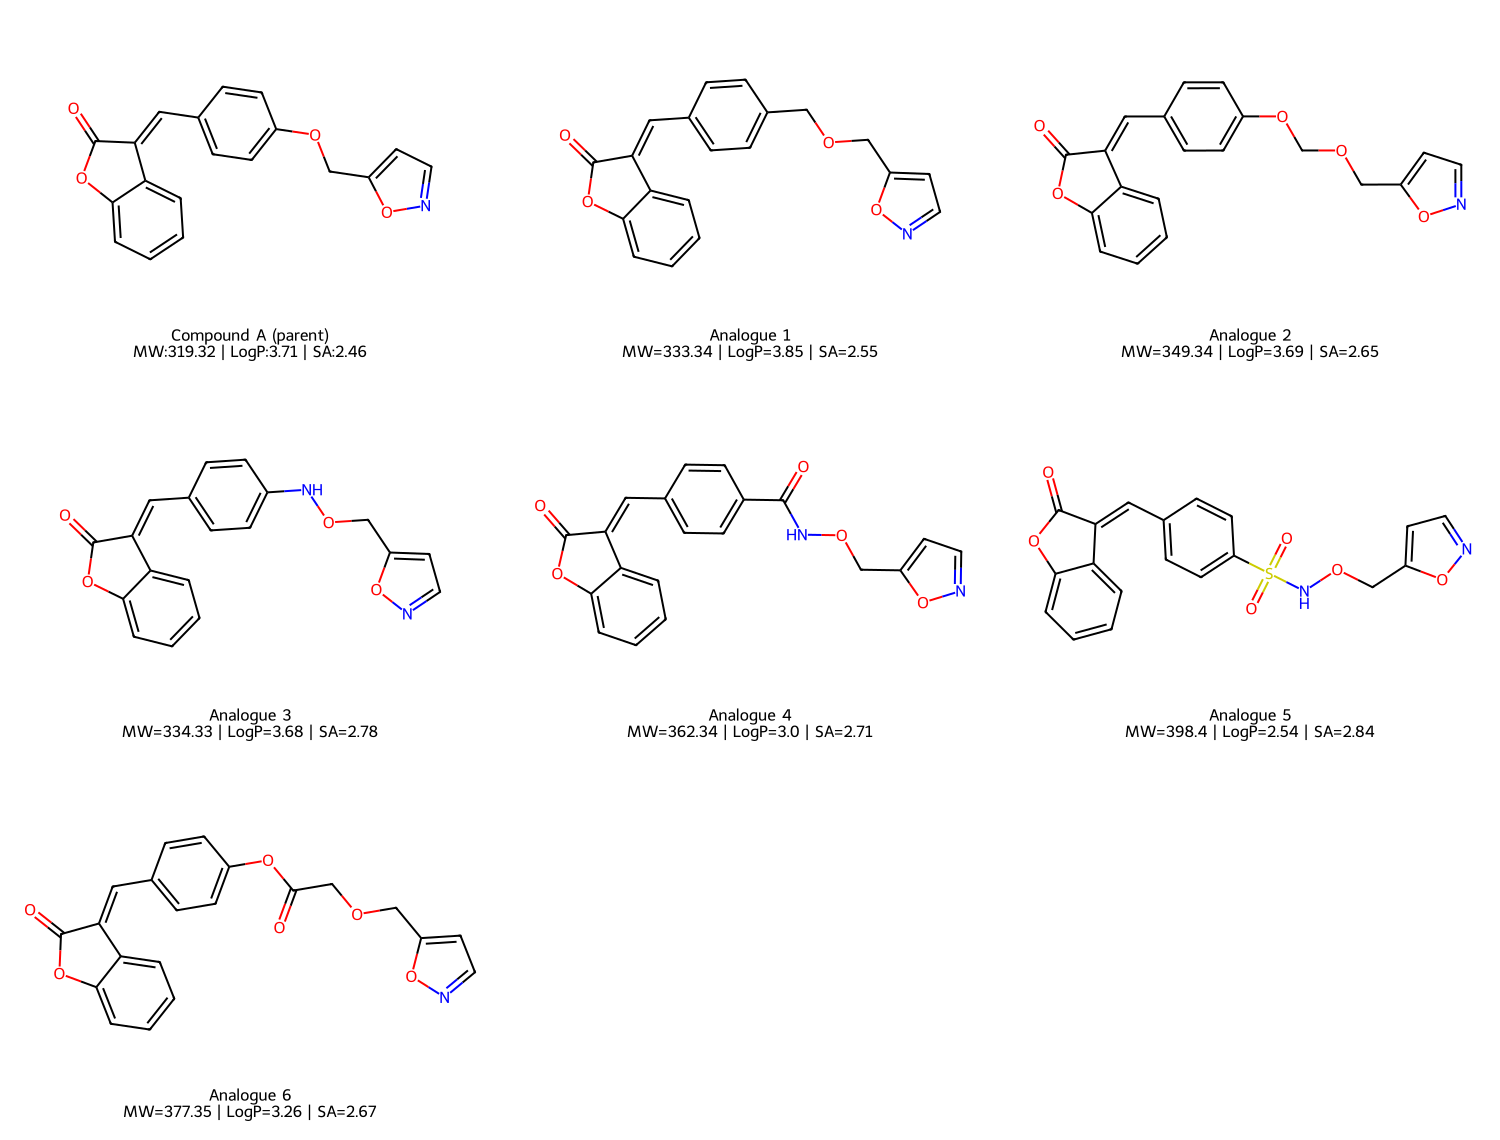

In [45]:
mols = [Chem.MolFromSmiles(s) for s in filtered_df['smiles']]

legends = [f"Analogue {i+1 if i > 0 else 'A (parent)'}\nMW:{row.MW} | LogP:{row.LogP} | SA:{row.SA_Score}" 
           if i > 0 else f"Compound A (parent)\nMW:{row.MW} | LogP:{row.LogP} | SA:{row.SA_Score}"
           for i, (_, row) in enumerate(filtered_df.iterrows())]

legends[0] = f"Compound A (parent)\nMW:{filtered_df.iloc[0].MW} | LogP:{filtered_df.iloc[0].LogP} | SA:{filtered_df.iloc[0].SA_Score}"
for i in range(1, len(legends)):
    row = filtered_df.iloc[i]
    legends[i] = f"Analogue {i}\nMW={row.MW} | LogP={row.LogP} | SA={row.SA_Score}"

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(500, 380),
    legends=legends,
    returnPNG=False
)

img